In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/archive (1)/retail_store_inventory.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [3]:
missing = df.isnull().sum()

print("Missing values by column:")
print(missing)

print("\nTotal missing values:", missing.sum())


Missing values by column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Total missing values: 0


In [4]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-01 00:00:00
Unique dates: 731


In [6]:
print(df["Date"].sort_values().head())
print()
print(df["Date"].sort_values().tail())

0    2022-01-01
72   2022-01-01
71   2022-01-01
70   2022-01-01
69   2022-01-01
Name: Date, dtype: datetime64[us]

73027   2024-01-01
73026   2024-01-01
73025   2024-01-01
73035   2024-01-01
73099   2024-01-01
Name: Date, dtype: datetime64[us]


In [7]:
print("Unique Stores:", df["Store ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())
print("Unique Categories:", df["Category"].nunique())
print("Unique Regions:", df["Region"].nunique())

print("\nStores:")
print(sorted(df["Store ID"].unique()))

print("\nProducts:")
print(sorted(df["Product ID"].unique()))

Unique Stores: 5
Unique Products: 20
Unique Categories: 5
Unique Regions: 4

Stores:
['S001', 'S002', 'S003', 'S004', 'S005']

Products:
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008', 'P0009', 'P0010', 'P0011', 'P0012', 'P0013', 'P0014', 'P0015', 'P0016', 'P0017', 'P0018', 'P0019', 'P0020']


In [8]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing"
]

print("Negative values:")
for col in numeric_cols:
    count = (df[col] < 0).sum()
    print(f"{col}: {count}")

Negative values:
Inventory Level: 0
Units Sold: 0
Units Ordered: 0
Demand Forecast: 673
Price: 0
Discount: 0
Holiday/Promotion: 0
Competitor Pricing: 0


In [9]:
negative_forecast = df[df["Demand Forecast"] < 0]

print("Negative forecast rows:", len(negative_forecast))

print("\nNegative forecast statistics:")
print(negative_forecast["Demand Forecast"].describe())

print("\nSample negative forecast rows:")
display(
    negative_forecast[
        ["Date", "Store ID", "Product ID", "Category",
         "Inventory Level", "Units Sold", "Demand Forecast"]
    ].head(20)
)

Negative forecast rows: 673

Negative forecast statistics:
count    673.000000
mean      -3.693730
std        2.535978
min       -9.990000
25%       -5.470000
50%       -3.380000
75%       -1.540000
max       -0.010000
Name: Demand Forecast, dtype: float64

Sample negative forecast rows:


,Date,Store ID,Product ID,Category,Inventory Level,Units Sold,Demand Forecast
63,2022-01-01,S004,P0004,Groceries,437,0,-2.40
141,2022-01-02,S003,P0002,Groceries,175,2,-3.40
278,2022-01-03,S004,P0019,Toys,140,1,-3.91
511,2022-01-06,S001,P0012,Groceries,59,1,-8.37
730,2022-01-08,S002,P0011,Electronics,64,7,-2.99
844,2022-01-09,S003,P0005,Furniture,418,4,-1.33
1011,2022-01-11,S001,P0012,Toys,205,3,-6.05
1107,2022-01-12,S001,P0008,Clothing,432,0,-3.55
1149,2022-01-12,S003,P0010,Furniture,74,6,-0.11
1180,2022-01-12,S005,P0001,Toys,132,6,-2.04


In [10]:
print("Units Sold statistics:")
print(df["Units Sold"].describe())

print("\nDemand Forecast statistics:")
print(df["Demand Forecast"].describe())

print("\nCorrelation with Units Sold:")
print(
    df[["Units Sold", "Demand Forecast", "Inventory Level",
        "Units Ordered", "Price", "Discount", "Competitor Pricing"]]
    .corr(numeric_only=True)["Units Sold"]
    .sort_values(ascending=False)
)

Units Sold statistics:
count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

Demand Forecast statistics:
count    73100.000000
mean       141.494720
std        109.254076
min         -9.990000
25%         53.670000
50%        113.015000
75%        208.052500
max        518.550000
Name: Demand Forecast, dtype: float64

Correlation with Units Sold:
Units Sold            1.000000
Demand Forecast       0.996853
Inventory Level       0.589995
Discount              0.002576
Competitor Pricing    0.001259
Price                 0.001082
Units Ordered        -0.000930
Name: Units Sold, dtype: float64


In [11]:
df["Forecast_Error"] = df["Demand Forecast"] - df["Units Sold"]

print("Forecast error statistics:")
print(df["Forecast_Error"].describe())

print("\nExact same values:",
      (df["Demand Forecast"] == df["Units Sold"]).sum())

print("\nMean absolute difference:",
      df["Forecast_Error"].abs().mean())

print("\nCorrelation:",
      df["Units Sold"].corr(df["Demand Forecast"]))

Forecast error statistics:
count    73100.000000
mean         5.029850
std          8.660766
min        -10.000000
25%         -2.470000
50%          4.990000
75%         12.510000
max         20.000000
Name: Forecast_Error, dtype: float64

Exact same values: 25

Mean absolute difference: 8.338075512995896

Correlation: 0.9968530435356842


In [12]:
categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


--- Store ID ---
Unique values: 5
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

--- Product ID ---
Unique values: 20
Product ID
P0001    3655
P0002    3655
P0003    3655
P0004    3655
P0005    3655
P0006    3655
P0007    3655
P0008    3655
P0009    3655
P0010    3655
Name: count, dtype: int64

--- Category ---
Unique values: 5
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

--- Region ---
Unique values: 4
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

--- Weather Condition ---
Unique values: 4
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

--- Seasonality ---
Unique values: 4
Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64


In [13]:
print("Inventory Level statistics:")
print(df["Inventory Level"].describe())

print("\nUnits Sold statistics:")
print(df["Units Sold"].describe())

print("\nInventory < Units Sold:")
print((df["Inventory Level"] < df["Units Sold"]).sum())

print("\nInventory = 0:")
print((df["Inventory Level"] == 0).sum())

Inventory Level statistics:
count    73100.000000
mean       274.469877
std        129.949514
min         50.000000
25%        162.000000
50%        273.000000
75%        387.000000
max        500.000000
Name: Inventory Level, dtype: float64

Units Sold statistics:
count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

Inventory < Units Sold:
0

Inventory = 0:
0


In [14]:
daily_sales = (
    df.groupby("Date")["Units Sold"]
      .sum()
      .reset_index()
)

print(daily_sales.head())
print("\nDaily sales statistics:")
print(daily_sales["Units Sold"].describe())

        Date  Units Sold
0 2022-01-01       14484
1 2022-01-02       13415
2 2022-01-03       13681
3 2022-01-04       14084
4 2022-01-05       12572

Daily sales statistics:
count      731.000000
mean     13646.487004
std       1031.958966
min      10642.000000
25%      12981.000000
50%      13673.000000
75%      14323.500000
max      17239.000000
Name: Units Sold, dtype: float64


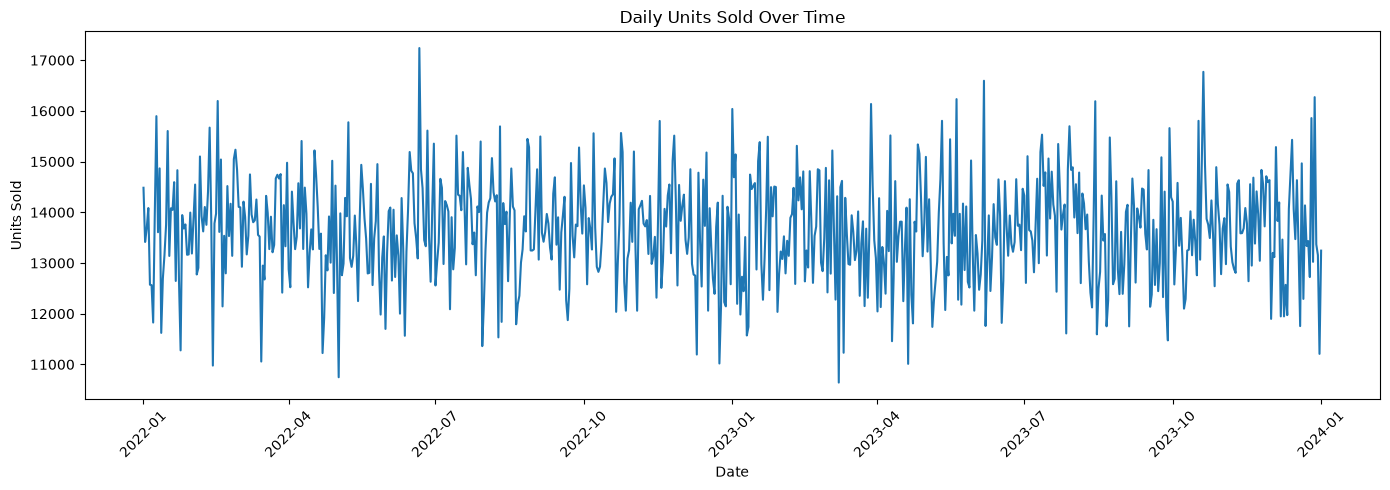

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"]
)

plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Units Sold"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = monthly_sales["Date"].dt.to_timestamp()

print(monthly_sales)

         Date  Units Sold
0  2022-01-01      419938
1  2022-02-01      391052
2  2022-03-01      426073
3  2022-04-01      407380
4  2022-05-01      414799
5  2022-06-01      415509
6  2022-07-01      426628
7  2022-08-01      424916
8  2022-09-01      411610
9  2022-10-01      426863
10 2022-11-01      414535
11 2022-12-01      412321
12 2023-01-01      423408
13 2023-02-01      385168
14 2023-03-01      416522
15 2023-04-01      401077
16 2023-05-01      418673
17 2023-06-01      405641
18 2023-07-01      437919
19 2023-08-01      416501
20 2023-09-01      405361
21 2023-10-01      425646
22 2023-11-01      416126
23 2023-12-01      418672
24 2024-01-01       13244


In [17]:
print("Records per month:")
print(
    df.groupby(df["Date"].dt.to_period("M"))
      .size()
)

Records per month:
Date
2022-01    3100
2022-02    2800
2022-03    3100
2022-04    3000
2022-05    3100
2022-06    3000
2022-07    3100
2022-08    3100
2022-09    3000
2022-10    3100
2022-11    3000
2022-12    3100
2023-01    3100
2023-02    2800
2023-03    3100
2023-04    3000
2023-05    3100
2023-06    3000
2023-07    3100
2023-08    3100
2023-09    3000
2023-10    3100
2023-11    3000
2023-12    3100
2024-01     100
Freq: M, dtype: int64


In [18]:
category_sales = (
    df.groupby("Category")["Units Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(category_sales)

                 sum        mean  count
Category                               
Furniture    2025017  137.765630  14699
Groceries    2000482  136.916159  14611
Clothing     1999166  136.685765  14626
Toys         1990485  135.934235  14643
Electronics  1960432  135.006680  14521


In [19]:
store_sales = (
    df.groupby("Store ID")["Units Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(store_sales)

              sum        mean  count
Store ID                            
S003      2022696  138.351300  14620
S005      2010176  137.494938  14620
S002      1987715  135.958618  14620
S004      1979245  135.379275  14620
S001      1975750  135.140219  14620


In [20]:
region_sales = (
    df.groupby("Region")["Units Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(region_sales)

            sum        mean  count
Region                            
East    2511265  136.861137  18349
South   2507799  137.060666  18297
North   2484966  136.326860  18228
West    2471552  135.605838  18226


In [21]:
promotion_analysis = (
    df.groupby("Holiday/Promotion")["Units Sold"]
      .agg(["sum", "mean", "count"])
)

print(promotion_analysis)

                       sum        mean  count
Holiday/Promotion                            
0                  5016163  136.505375  36747
1                  4959419  136.423926  36353


In [22]:
weather_analysis = (
    df.groupby("Weather Condition")["Units Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("mean", ascending=False)
)

print(weather_analysis)

                       sum        mean  count
Weather Condition                            
Sunny              2524544  138.028650  18290
Cloudy             2497207  136.758324  18260
Snowy              2483376  135.911559  18272
Rainy              2470455  135.160028  18278


In [23]:
seasonality_analysis = (
    df.groupby("Seasonality")["Units Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("mean", ascending=False)
)

print(seasonality_analysis)

                 sum        mean  count
Seasonality                            
Autumn       2506676  137.782444  18193
Winter       2501951  136.830790  18285
Spring       2487940  135.826828  18317
Summer       2479015  135.428298  18305


In [24]:
# Create calendar/time-based features

df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

print("Calendar features created successfully!")

display(
    df[
        [
            "Date",
            "Store ID",
            "Product ID",
            "Year",
            "Month",
            "Day",
            "DayOfWeek",
            "WeekOfYear"
        ]
    ].head(10)
)

Calendar features created successfully!


,Date,Store ID,Product ID,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,S001,P0001,2022,1,1,5,52
1,2022-01-02,S001,P0001,2022,1,2,6,52
2,2022-01-03,S001,P0001,2022,1,3,0,1
3,2022-01-04,S001,P0001,2022,1,4,1,1
4,2022-01-05,S001,P0001,2022,1,5,2,1
5,2022-01-06,S001,P0001,2022,1,6,3,1
6,2022-01-07,S001,P0001,2022,1,7,4,1
7,2022-01-08,S001,P0001,2022,1,8,5,1
8,2022-01-09,S001,P0001,2022,1,9,6,1
9,2022-01-10,S001,P0001,2022,1,10,0,2


In [25]:
# Create lag features at Store-Product level

group_cols = ["Store ID", "Product ID"]

df["Lag_1"] = (
    df.groupby(group_cols)["Units Sold"]
      .shift(1)
)

df["Lag_7"] = (
    df.groupby(group_cols)["Units Sold"]
      .shift(7)
)

df["Lag_14"] = (
    df.groupby(group_cols)["Units Sold"]
      .shift(14)
)

df["Lag_28"] = (
    df.groupby(group_cols)["Units Sold"]
      .shift(28)
)

print("Lag features created successfully!")

display(
    df[
        [
            "Date",
            "Store ID",
            "Product ID",
            "Units Sold",
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Lag_28"
        ]
    ].head(35)
)

Lag features created successfully!


,Date,Store ID,Product ID,Units Sold,Lag_1,Lag_7,Lag_14,Lag_28
0,2022-01-01,S001,P0001,127,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,81,127.0,NaN,NaN,NaN
2,2022-01-03,S001,P0001,5,81.0,NaN,NaN,NaN
3,2022-01-04,S001,P0001,58,5.0,NaN,NaN,NaN
4,2022-01-05,S001,P0001,147,58.0,NaN,NaN,NaN
5,2022-01-06,S001,P0001,37,147.0,NaN,NaN,NaN
6,2022-01-07,S001,P0001,107,37.0,NaN,NaN,NaN
7,2022-01-08,S001,P0001,2,107.0,127.0,NaN,NaN
8,2022-01-09,S001,P0001,350,2.0,81.0,NaN,NaN
9,2022-01-10,S001,P0001,36,350.0,5.0,NaN,NaN


In [26]:
# Create rolling demand features

df["Rolling_Mean_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

df["Rolling_Mean_14"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(window=14).mean())
)

df["Rolling_Mean_28"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(window=28).mean())
)

print("Rolling features created successfully!")

display(
    df[
        [
            "Date",
            "Store ID",
            "Product ID",
            "Units Sold",
            "Rolling_Mean_7",
            "Rolling_Mean_14",
            "Rolling_Mean_28"
        ]
    ].head(35)
)

Rolling features created successfully!


,Date,Store ID,Product ID,Units Sold,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_28
0,2022-01-01,S001,P0001,127,NaN,NaN,NaN
1,2022-01-02,S001,P0001,81,NaN,NaN,NaN
2,2022-01-03,S001,P0001,5,NaN,NaN,NaN
3,2022-01-04,S001,P0001,58,NaN,NaN,NaN
4,2022-01-05,S001,P0001,147,NaN,NaN,NaN
5,2022-01-06,S001,P0001,37,NaN,NaN,NaN
6,2022-01-07,S001,P0001,107,NaN,NaN,NaN
7,2022-01-08,S001,P0001,2,80.285714,NaN,NaN
8,2022-01-09,S001,P0001,350,62.428571,NaN,NaN
9,2022-01-10,S001,P0001,36,100.857143,NaN,NaN


In [27]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (73100, 28)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Forecast_Error', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_28']

Date range:
2022-01-01 00:00:00 to 2024-01-01 00:00:00

Missing values:
Date                     0
Store ID                 0
Product ID               0
Category                 0
Region                   0
Inventory Level          0
Units Sold               0
Units Ordered            0
Demand Forecast          0
Price                    0
Discount                 0
Weather Condition        0
Holiday/Promotion        0
Competitor Pricing       0
Seasonality              0
Forecast_Error           0
Year                     0
Month                    0
Day            

In [28]:
# Time-based train / validation / test split

train = df[
    (df["Date"] >= "2022-01-01") &
    (df["Date"] < "2023-07-01")
].copy()

validation = df[
    (df["Date"] >= "2023-07-01") &
    (df["Date"] < "2023-10-01")
].copy()

test = df[
    (df["Date"] >= "2023-10-01") &
    (df["Date"] < "2024-01-01")
].copy()

print("TRAIN")
print("Rows:", len(train))
print("Date:", train["Date"].min(), "to", train["Date"].max())

print("\nVALIDATION")
print("Rows:", len(validation))
print("Date:", validation["Date"].min(), "to", validation["Date"].max())

print("\nTEST")
print("Rows:", len(test))
print("Date:", test["Date"].min(), "to", test["Date"].max())

TRAIN
Rows: 54600
Date: 2022-01-01 00:00:00 to 2023-06-30 00:00:00

VALIDATION
Rows: 9200
Date: 2023-07-01 00:00:00 to 2023-09-30 00:00:00

TEST
Rows: 9200
Date: 2023-10-01 00:00:00 to 2023-12-31 00:00:00


In [29]:
print("TRAIN missing:")
print(train[["Lag_1", "Lag_7", "Lag_14", "Lag_28",
             "Rolling_Mean_7", "Rolling_Mean_14", "Rolling_Mean_28"]].isna().sum())

print("\nVALIDATION missing:")
print(validation[["Lag_1", "Lag_7", "Lag_14", "Lag_28",
                  "Rolling_Mean_7", "Rolling_Mean_14", "Rolling_Mean_28"]].isna().sum())

print("\nTEST missing:")
print(test[["Lag_1", "Lag_7", "Lag_14", "Lag_28",
            "Rolling_Mean_7", "Rolling_Mean_14", "Rolling_Mean_28"]].isna().sum())

TRAIN missing:
Lag_1               100
Lag_7               700
Lag_14             1400
Lag_28             2800
Rolling_Mean_7      700
Rolling_Mean_14    1400
Rolling_Mean_28    2800
dtype: int64

VALIDATION missing:
Lag_1              0
Lag_7              0
Lag_14             0
Lag_28             0
Rolling_Mean_7     0
Rolling_Mean_14    0
Rolling_Mean_28    0
dtype: int64

TEST missing:
Lag_1              0
Lag_7              0
Lag_14             0
Lag_28             0
Rolling_Mean_7     0
Rolling_Mean_14    0
Rolling_Mean_28    0
dtype: int64


In [30]:
# Remove rows without sufficient historical information for training

feature_cols_lag = [
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_28"
]

train_clean = train.dropna(subset=feature_cols_lag).copy()

print("Original train rows:", len(train))
print("Clean train rows:", len(train_clean))
print("Rows removed:", len(train) - len(train_clean))

print("\nRemaining missing values:")
print(train_clean[feature_cols_lag].isna().sum())

Original train rows: 54600
Clean train rows: 51800
Rows removed: 2800

Remaining missing values:
Lag_1              0
Lag_7              0
Lag_14             0
Lag_28             0
Rolling_Mean_7     0
Rolling_Mean_14    0
Rolling_Mean_28    0
dtype: int64


In [31]:
# Define target and modelling features

target = "Units Sold"

features = [
    # Calendar features
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",

    # Historical demand
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_28",

    # Inventory / business features
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing",

    # Categorical business features
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Store ID",
    "Product ID"
]

print("Target:", target)
print("\nNumber of features:", len(features))
print("\nFeatures:")
for i, col in enumerate(features, 1):
    print(f"{i}. {col}")

Target: Units Sold

Number of features: 24

Features:
1. Year
2. Month
3. Day
4. DayOfWeek
5. WeekOfYear
6. Lag_1
7. Lag_7
8. Lag_14
9. Lag_28
10. Rolling_Mean_7
11. Rolling_Mean_14
12. Rolling_Mean_28
13. Inventory Level
14. Units Ordered
15. Price
16. Discount
17. Holiday/Promotion
18. Competitor Pricing
19. Category
20. Region
21. Weather Condition
22. Seasonality
23. Store ID
24. Product ID


In [32]:
categorical_cols = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Store ID",
    "Product ID"
]

numeric_cols = [
    col for col in features
    if col not in categorical_cols
]

print("Categorical features:", len(categorical_cols))
print(categorical_cols)

print("\nNumeric features:", len(numeric_cols))
print(numeric_cols)

Categorical features: 6
['Category', 'Region', 'Weather Condition', 'Seasonality', 'Store ID', 'Product ID']

Numeric features: 18
['Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_28', 'Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train = preprocessor.fit_transform(train_clean[features])
X_val = preprocessor.transform(validation[features])
X_test = preprocessor.transform(test[features])

y_train = train_clean[target]
y_val = validation[target]
y_test = test[target]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (51800, 60)
X_val shape: (9200, 60)
X_test shape: (9200, 60)

y_train shape: (51800,)
y_val shape: (9200,)
y_test shape: (9200,)


In [34]:
feature_names = preprocessor.get_feature_names_out()

print("Total encoded features:", len(feature_names))
print("\nFirst 20 feature names:")
print(feature_names[:20])

Total encoded features: 60

First 20 feature names:
['cat__Category_Clothing' 'cat__Category_Electronics'
 'cat__Category_Furniture' 'cat__Category_Groceries' 'cat__Category_Toys'
 'cat__Region_East' 'cat__Region_North' 'cat__Region_South'
 'cat__Region_West' 'cat__Weather Condition_Cloudy'
 'cat__Weather Condition_Rainy' 'cat__Weather Condition_Snowy'
 'cat__Weather Condition_Sunny' 'cat__Seasonality_Autumn'
 'cat__Seasonality_Spring' 'cat__Seasonality_Summer'
 'cat__Seasonality_Winter' 'cat__Store ID_S001' 'cat__Store ID_S002'
 'cat__Store ID_S003']


In [35]:
import os
import pandas as pd

os.makedirs("../data/processed", exist_ok=True)

# Save model-ready datasets
pd.DataFrame(X_train, columns=feature_names).to_csv(
    "../data/processed/train_features.csv", index=False
)

pd.DataFrame(X_val, columns=feature_names).to_csv(
    "../data/processed/validation_features.csv", index=False
)

pd.DataFrame(X_test, columns=feature_names).to_csv(
    "../data/processed/test_features.csv", index=False
)

# Save targets
y_train.to_csv("../data/processed/train_target.csv", index=False)
y_val.to_csv("../data/processed/validation_target.csv", index=False)
y_test.to_csv("../data/processed/test_target.csv", index=False)

# Save feature names
pd.Series(feature_names).to_csv(
    "../data/processed/feature_names.csv", index=False
)

print("All processed datasets saved successfully!")

All processed datasets saved successfully!
